# 作业 3a：生成对抗样本（Adversarial Examples）

在本作业中，你需要生成 5 张对抗样本图像，用以误导机器学习模型产生错误分类。这个任务与实践课非常相似，请在开始前认真回看实践内容并确保理解其原理与步骤。
 
作业使用的数据集为 **FashionMNIST**，包含多种服饰类型的灰度图像。每张图像被划分到 10 个服饰类别中的一个。


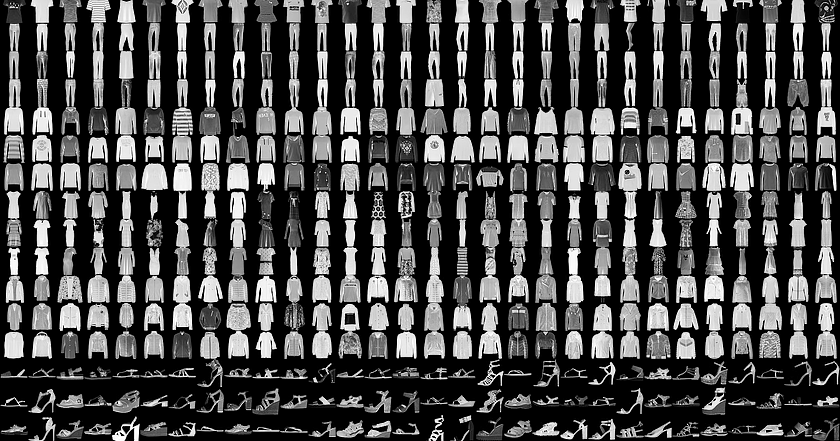

训练集与测试集中的每个样本都属于下表中的某一标签：

| Label | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |:---: | :---: |:---: | :---: |
|  | T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |

现在请创建一个名为 `classes` 的列表，用字符串存放上述标签，并输出这个列表。

期望输出：

     ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [1]:
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


在开始训练深度学习模型之前，请导入必要的Python库。这些库与模块 4 与模块 5 的实践活动中介绍的相同。

In [2]:
# 在开始训练深度学习模型之前，请导入必要的Python库。这些库与模块 4 与模块 5 的实践活动中介绍的相同。

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


接下来为模型训练声明若干超参数（hyperparameters），包括：**训练轮数（training epochs）**、**批大小（batch size）**与**学习率（learning rate）**。  
训练轮数可以设为大于 10 的任意整数；批大小可设为 32、64 或 100；学习率设为 0.001。


In [3]:
# 接下来为模型训练声明若干超参数（hyperparameters），包括：**训练轮数（training epochs）**、**批大小（batch size）**与**学习率（learning rate）**。  
# 训练轮数可以设为大于 10 的任意整数；批大小可设为 32、64 或 100；学习率设为 0.001.


epochs = 15 # 訓練倫數可以設為大於 10 的任意整數
batch_size = 64 # 批大小可設為 32、64 或 100
learning_rate = 0.001 # 學習率設為 0.001

加载训练集与测试集。所需数据集名称为 **`FashionMNIST`**。获取数据集的方式与实践课一样，只需将 `'MNIST'` 替换为 `'FashionMNIST'`。


In [4]:
# 加载训练集与测试集。所需数据集名称为 **`FashionMNIST`**。获取数据集的方式与实践课一样，只需将 `'MNIST'` 替换为 `'FashionMNIST'`。
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True) # 加載訓練集，將圖像轉換為張量格式
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True) # 加載測試集，將圖像轉換為張量格式
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True) # 創建訓練數據加載器，設置批大小並啟用數據洗牌
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False) # 創建測試數據加載器，設置批大小但不啟用數據洗牌


100%|██████████| 26.4M/26.4M [00:08<00:00, 3.06MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 105kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.37MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


请分别输出训练集与测试集的样本数量。

期望输出：
    训练集的样本数量：  60000
    测试集的样本数量：  10000

In [ ]:
# 请分别输出训练集与测试集的样本数量。

# 期望输出： 1.训练集的样本数量：60000 ; 2.测试集的样本数量： 10000

print(f"訓練集的样本数量：{len(train_dataset)}")
print(f"測試集的样本数量：{len(test_dataset)}")

訓練集的样本数量：60000
測試集的样本数量：10000


展示训练集前 5 张图像的内容以了解其样式。  
在本作业中，你需要针对这前五张图像生成对抗样本。只需要修改训练集索引，并为 5 张图像分别创建 5 个变量。

第三张图像示例：
    
    img3 = training_dataset[2][0].squeeze(0).data

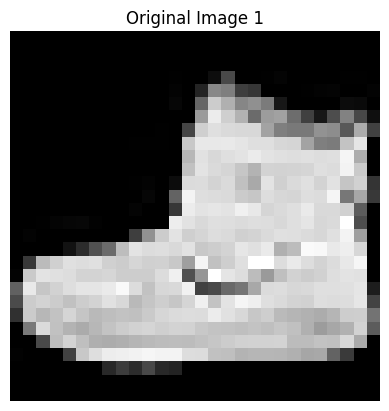

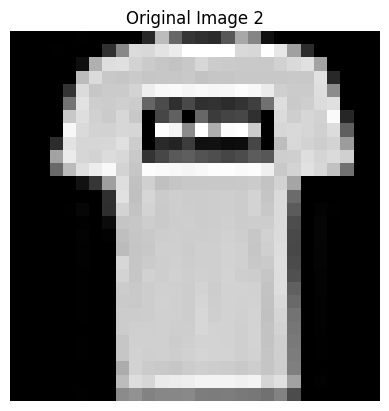

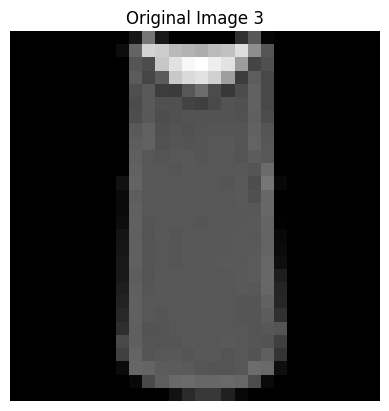

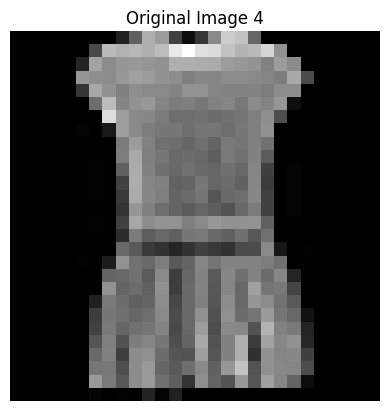

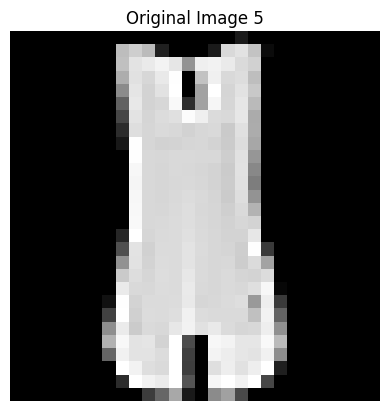

In [6]:
# 展示训练集前 5 张图像的内容以了解其样式。  
# 在本作业中，你需要针对这前五张图像生成对抗样本。只需要修改训练集索引，并为 5 张图像分别创建 5 个变量。

# 第三张图像示例：
    
#     img3 = training_dataset[2][0].squeeze(0).data

for i in range(5):
    img = train_dataset[i][0].squeeze(0).data
    plt.imshow(img, cmap='gray')
    plt.title(f"Original Image {i+1}")
    plt.axis('off')
    plt.show()

本作业中沿用实践活动中的同一模型结构来构建并训练模型。请用实践课的代码补充模型。

In [7]:
# 本作业中沿用实践活动中的同一模型结构来构建并训练模型。请用实践课的代码补充模型。

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

开始训练模型。训练轮数使用你在上文设定的值，这意味着训练数据将被在模型中传递相应的次数。训练耗时取决于不同设备的计算能力。同样地，添加实践课中的代码来训练模型。


In [8]:
# 开始训练模型。训练轮数使用你在上文设定的值，这意味着训练数据将被在模型中传递相应的次数。训练耗时取决于不同设备的计算能力。同样地，添加实践课中的代码来训练模型。
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    



Epoch [1/15], Loss: 0.4441
Epoch [2/15], Loss: 0.2883
Epoch [3/15], Loss: 0.2433
Epoch [4/15], Loss: 0.2156
Epoch [5/15], Loss: 0.1897
Epoch [6/15], Loss: 0.1704
Epoch [7/15], Loss: 0.1507
Epoch [8/15], Loss: 0.1332
Epoch [9/15], Loss: 0.1153
Epoch [10/15], Loss: 0.1011
Epoch [11/15], Loss: 0.0858
Epoch [12/15], Loss: 0.0749
Epoch [13/15], Loss: 0.0644
Epoch [14/15], Loss: 0.0538
Epoch [15/15], Loss: 0.0480


现在使用测试集评估模型。你需要：  
1）展示在 **10000** 张测试图像上的总体准确率；  
2）分别报告**每个类别**上的准确率（类别名称已经在上面构建）。只需要使用 `classes[n]`，其中 *n* 为标签整数。比如：'T-shirt/top' 是 'classes[0]'.

示例输出：

模型在10000张测试图像上的测试准确率： ** %

模型在类别'T-shirt/top'上的测试准确率： ** %

...

In [9]:
# 现在使用测试集评估模型。你需要：  
# 1）展示在 **10000** 张测试图像上的总体准确率；  
# 2）分别报告**每个类别**上的准确率（类别名称已经在上面构建）。只需要使用 `classes[n]`，其中 *n* 为标签整数。比如：'T-shirt/top' 是 'classes[0]'.

# 示例输出：

# 模型在10000张测试图像上的测试准确率： ** %

# 模型在类别'T-shirt/top'上的测试准确率： ** %

model.eval()
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        for i in range(len(labels)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
print(f"模型在10000张测试图像上的测试准确率： {100 * correct / total:.2f} %")
for i in range(10):
    print(f"模型在类别'{classes[i]}'上的测试准确率： {100 * class_correct[i] / class_total[i]:.2f} %")



模型在10000张测试图像上的测试准确率： 91.98 %
模型在类别'T-shirt/top'上的测试准确率： 86.40 %
模型在类别'Trouser'上的测试准确率： 98.40 %
模型在类别'Pullover'上的测试准确率： 84.00 %
模型在类别'Dress'上的测试准确率： 93.30 %
模型在类别'Coat'上的测试准确率： 88.70 %
模型在类别'Sandal'上的测试准确率： 97.70 %
模型在类别'Shirt'上的测试准确率： 78.50 %
模型在类别'Sneaker'上的测试准确率： 97.60 %
模型在类别'Bag'上的测试准确率： 97.90 %
模型在类别'Ankle boot'上的测试准确率： 97.30 %


测试训练集第一张图像（你已在上方输出）的预测标签。

期望输出：

    "Trouser"

In [ ]:
# 测试训练集第一张图像（你已在上方输出）的预测标签。

# 期望输出："Trouser"
model.eval()
with torch.no_grad():
    img = train_dataset[0][0].unsqueeze(0).to(device)  # 获取第一张图像并添加批次维度
    output = model(img)
    _, predicted_label = torch.max(output.data, 1)
    print(f"预测标签: {classes[predicted_label.item()]}")
    


预测标签: Ankle boot


## 生成对抗样本

要生成对抗图像，需要构造与原图相同形状（32×32）的扰动噪声。如实践课程所述，噪声过大将使对抗样本不能被人眼识别，而噪声过小可能无法误导模型。  
请谨慎缩放噪声幅度，目标是在尽可能小的噪声下成功误导模型。

然后将生成的噪声分别叠加到五张原始图像上，并输出这 5 张带噪声图像。注意，只需要为前五张图片生成对抗样本。

请展示 5 张对抗图像、它们的原始标签以及模型给出的预测标签；并将 5 张原图与 5 张对抗图像输出进行对比展示。